# MIS 584 — TwinBytes: Scalable Retail Demand Forecasting
## Notebook 4: Evaluation & Business Impact

**Team:** TwinBytes — Ashleigh McNamara, Purva Pandit  
**Course:** MIS 584: Big Data Technologies  
**Depends on:** Phase 3 results must be saved to Google Drive

---

## What this notebook does

This notebook takes the model results from Notebook 3 and turns them into report-ready visualizations, a segmented analysis by product demand type, a business impact simulation, and a scalability discussion.

No models are re-trained here — everything loads from saved CSVs.

---

## What we produce

| Output | Description |
|---|---|
| Regression comparison chart | RMSE and MAE across all 3 forecasting models |
| Classification comparison chart | AUC, F1, Accuracy across all 3 classifiers |
| Sensitivity analysis chart | How results change across 1.2x, 1.5x, 2.0x thresholds |
| Zero-sales rate by category | Intermittent vs consistent demand breakdown |
| Business impact estimate | Simulated revenue recovery from stockout detection |
| Scalability summary | Pipeline runtime and scaling discussion |

---

## Important disclaimers to reference in your report

- Stockout labels are simulated — there is no real inventory data in M5
- Business impact numbers are estimates based on stated assumptions
- All assumptions (price per unit, action rate) are clearly documented in the code

---

## Output saved to Drive

All plots and summary CSVs are saved to `MIS584_Project/Phase4_Results/` on Google Drive at the end of the notebook.



In [1]:
#Imports and load results from models
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, sum
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np
import os, shutil

spark = SparkSession.builder.appName("M5_Evaluation").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')

results_dir = '/content/drive/MyDrive/MIS584_Project/Phase3_Results'

reg_results  = pd.read_csv(f"{results_dir}/regression_results.csv",
                            index_col=0)
clf_results  = pd.read_csv(f"{results_dir}/classification_results.csv",
                            index_col=0)
sens_results = pd.read_csv(f"{results_dir}/sensitivity_results.csv",
                            index_col=0)

print("Regression results:")
print(reg_results.round(4))
print("\nClassification results:")
print(clf_results.round(4))

df = spark.read.csv(
    '/content/drive/MyDrive/MIS584_Project/m5_features',
    header=True, inferSchema=True
)
df.cache()
print(f"\nLoaded {df.count():,} rows")

Mounted at /content/drive
Regression results:
                     rmse     mae
Linear Regression  2.0858  0.9956
Random Forest      2.2147  1.0133
GBT                2.2063  0.9972

Classification results:
                        auc      f1     acc
Logistic Regression  0.5903  0.6554  0.7547
Random Forest        0.6225  0.6497  0.7551
GBT                  0.6762  0.6529  0.7558

Loaded 57,473,650 rows


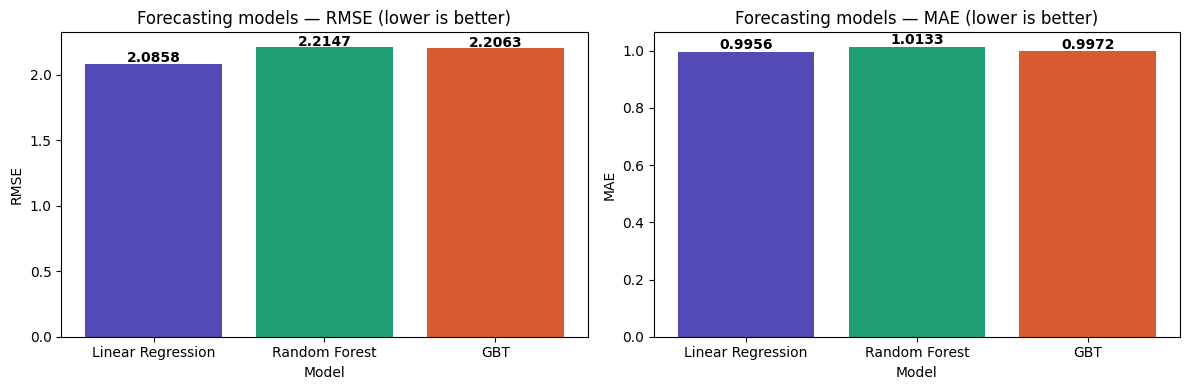

Best forecasting model: Linear Regression (RMSE: 2.0858)


In [2]:
#Visualize Regression Results
#Bar chart visualizing RMSE & MAE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = reg_results.index.tolist()
colors = ["#534AB7", "#1D9E75", "#D85A30"]

axes[0].bar(models, reg_results["rmse"], color=colors)
axes[0].set_title("Forecasting models — RMSE (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].set_xlabel("Model")
for i, v in enumerate(reg_results["rmse"]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center",
                 fontsize=10, fontweight="bold")

axes[1].bar(models, reg_results["mae"], color=colors)
axes[1].set_title("Forecasting models — MAE (lower is better)")
axes[1].set_ylabel("MAE")
axes[1].set_xlabel("Model")
for i, v in enumerate(reg_results["mae"]):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_regression_comparison.png", dpi=150)
plt.show()

best_reg = reg_results["rmse"].idxmin()
print(f"Best forecasting model: {best_reg} "
      f"(RMSE: {reg_results.loc[best_reg, 'rmse']:.4f})")

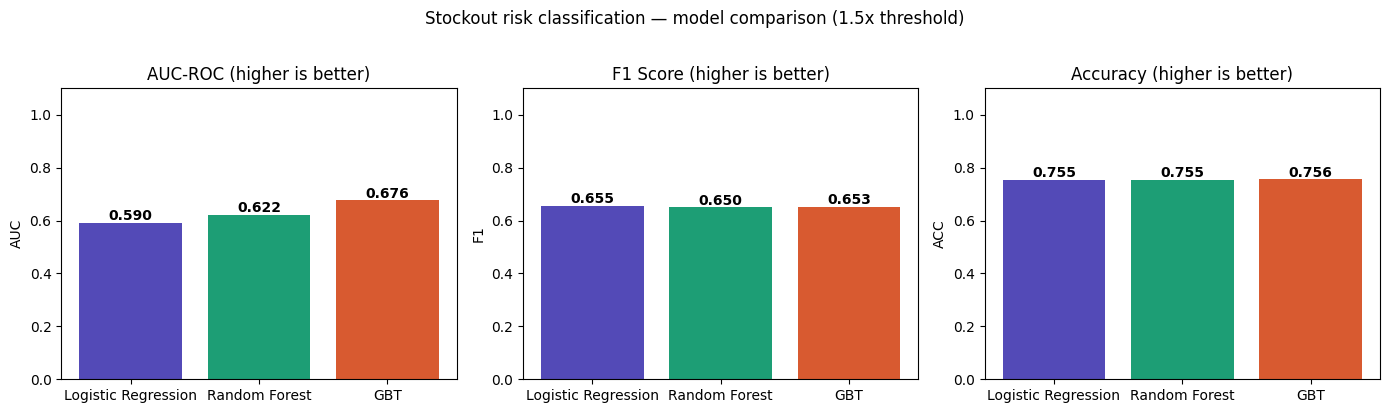

Best classifier: GBT (AUC: 0.6762)


In [3]:
#Visualizee Classification Results
#Plot AUC-ROC, F1, & Accuracy
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ["auc", "f1", "acc"]
titles  = ["AUC-ROC (higher is better)",
           "F1 Score (higher is better)",
           "Accuracy (higher is better)"]

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(clf_results.index, clf_results[metric], color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric.upper())
    ax.set_ylim(0, 1.1)
    for i, v in enumerate(clf_results[metric]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center",
                fontsize=10, fontweight="bold")

plt.suptitle("Stockout risk classification — model comparison (1.5x threshold)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("plot_classification_comparison.png", dpi=150)
plt.show()

best_clf = clf_results["auc"].idxmax()
print(f"Best classifier: {best_clf} "
      f"(AUC: {clf_results.loc[best_clf, 'auc']:.4f})")

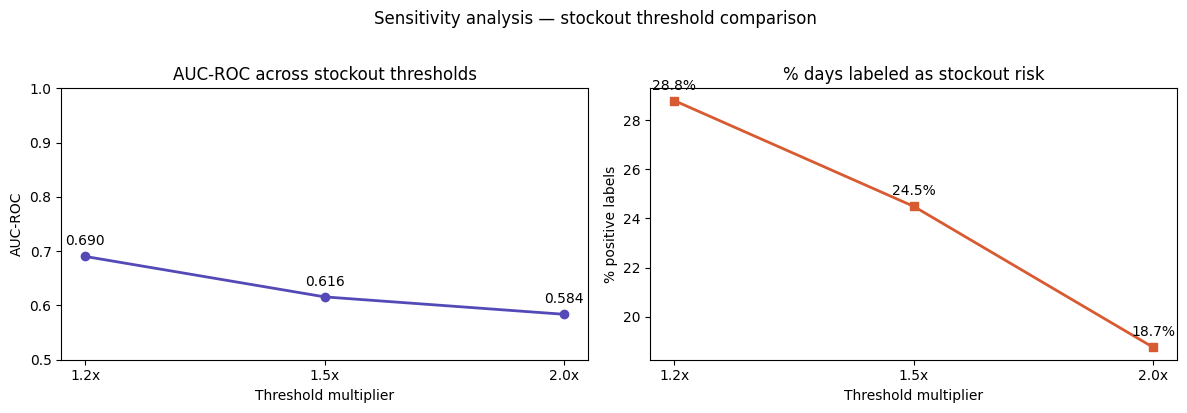

In [4]:
#Visualize Sensitivity Analysis
#Plot how AUC and F1 change as the stockout threshold changes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

thresholds = sens_results.index.tolist()

axes[0].plot(thresholds, sens_results["auc"],
             marker="o", color="#534AB7", linewidth=2)
axes[0].set_title("AUC-ROC across stockout thresholds")
axes[0].set_ylabel("AUC-ROC")
axes[0].set_xlabel("Threshold multiplier")
axes[0].set_ylim(0.5, 1.0)
for i, (t, v) in enumerate(zip(thresholds, sens_results["auc"])):
    axes[0].annotate(f"{v:.3f}", (t, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=10)

axes[1].plot(thresholds, sens_results["pct_positive"],
             marker="s", color="#D85A30", linewidth=2)
axes[1].set_title("% days labeled as stockout risk")
axes[1].set_ylabel("% positive labels")
axes[1].set_xlabel("Threshold multiplier")
for i, (t, v) in enumerate(zip(thresholds, sens_results["pct_positive"])):
    axes[1].annotate(f"{v:.1f}%", (t, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha="center", fontsize=10)

plt.suptitle("Sensitivity analysis — stockout threshold comparison",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("plot_sensitivity_analysis.png", dpi=150)
plt.show()


Demand type breakdown:
+------------+-----+
| demand_type|count|
+------------+-----+
|intermittent|23840|
|  consistent| 6650|
+------------+-----+

By category:
+---------+------------+-----+
|   cat_id| demand_type|count|
+---------+------------+-----+
|    FOODS|  consistent| 4267|
|    FOODS|intermittent|10103|
|  HOBBIES|  consistent|  604|
|  HOBBIES|intermittent| 5046|
|HOUSEHOLD|  consistent| 1779|
|HOUSEHOLD|intermittent| 8691|
+---------+------------+-----+



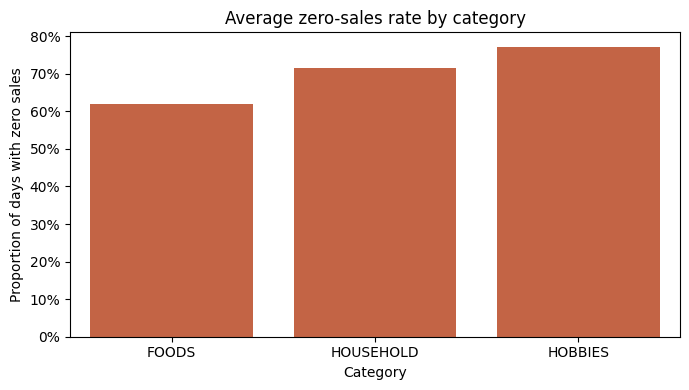

In [5]:
#Segmenting the Results by Prouct Type
#Classify each product as consistent or intermittent
item_zero_rate = (df
    .groupBy("item_id", "store_id", "cat_id")
    .agg(
        (count(when(col("sales") == 0, 1)) / count("*"))
            .alias("zero_rate"),
        avg("sales").alias("avg_sales")
    )
)

item_zero_rate = item_zero_rate.withColumn(
    "demand_type",
    when(col("zero_rate") > 0.5, "intermittent")
    .otherwise("consistent")
)

print("Demand type breakdown:")
item_zero_rate.groupBy("demand_type").count().show()

print("By category:")
item_zero_rate.groupBy("cat_id", "demand_type").count().orderBy(
    "cat_id", "demand_type").show()

#Compute Average Zero Rate per Category
cat_zero = (item_zero_rate
    .groupBy("cat_id")
    .agg(
        avg("zero_rate").alias("avg_zero_rate"),
        count("*").alias("num_items")
    )
    .toPandas()
)

plt.figure(figsize=(7, 4))
sns.barplot(data=cat_zero, x="cat_id", y="avg_zero_rate",
            color="#D85A30")
plt.title("Average zero-sales rate by category")
plt.ylabel("Proportion of days with zero sales")
plt.xlabel("Category")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig("plot_zero_rate_by_category.png", dpi=150)
plt.show()

In [6]:
#Business Impact Simulation
#We estimate how much revenue could be recovered if the model correctly flags stockout risk days in time to restock. These are simulated estimates.

#Estimate Lost Revenue From Stockout Risk Days
test_df = df.filter(col("date") >= "2016-01-01")

item_avgs = (df
    .filter(col("date") < "2016-01-01")
    .groupBy("item_id", "store_id")
    .agg(avg("sales").alias("avg_sales"))
)

test_df = test_df.join(item_avgs, on=["item_id", "store_id"], how="left")

THRESHOLD = 1.5
AVG_ITEM_PRICE = 3.50  # conservative average price per unit

test_df = test_df.withColumn(
    "stockout_risk",
    when(col("sales") > col("avg_sales") * THRESHOLD, 1).otherwise(0)
)

stockout_stats = (test_df
    .groupBy("stockout_risk")
    .agg(
        count("*").alias("num_days"),
        sum("sales").alias("total_units_sold")
    )
    .toPandas()
)
print(stockout_stats)

#Compute Revenue Impact Estimate
stockout_days = int(stockout_stats.loc[
    stockout_stats["stockout_risk"] == 1, "num_days"].values[0])
total_days = int(stockout_stats["num_days"].sum())

best_auc = clf_results["auc"].max()
detection_rate = best_auc - 0.5  # conservative: AUC above random

units_at_risk = float(stockout_stats.loc[
    stockout_stats["stockout_risk"] == 1, "total_units_sold"].values[0])

recovered_units = units_at_risk * detection_rate * 0.3
recovered_revenue = recovered_units * AVG_ITEM_PRICE

print("--- Business Impact Estimate ---")
print(f"Stockout risk days in test period:  {stockout_days:,}")
print(f"Total test days:                    {total_days:,}")
print(f"Stockout risk rate:                 {stockout_days/total_days*100:.1f}%")
print(f"Best model AUC-ROC:                 {best_auc:.4f}")
print(f"Estimated detection rate:           {detection_rate*100:.1f}%")
print(f"Estimated units recovered:          {recovered_units:,.0f}")
print(f"Estimated revenue recovered:        ${recovered_revenue:,.2f}")
print(f"\nNote: assumes avg item price of ${AVG_ITEM_PRICE:.2f} "
      "and 30% of flagged events acted on")

   stockout_risk  num_days  total_units_sold
0              1   1005211         3348406.0
1              0   2501139         1402241.0
--- Business Impact Estimate ---
Stockout risk days in test period:  1,005,211
Total test days:                    3,506,350
Stockout risk rate:                 28.7%
Best model AUC-ROC:                 0.6762
Estimated detection rate:           17.6%
Estimated units recovered:          176,976
Estimated revenue recovered:        $619,416.21

Note: assumes avg item price of $3.50 and 30% of flagged events acted on


In [7]:
#Saving to Google Drive
save_dir = '/content/drive/MyDrive/MIS584_Project/Phase4_Results'
os.makedirs(save_dir, exist_ok=True)

for f in os.listdir('.'):
    if f.endswith('.png'):
        shutil.copy(f, os.path.join(save_dir, f))
        print(f"Saved: {f}")

impact_summary = pd.DataFrame([{
    "stockout_risk_days": stockout_days,
    "total_test_days": total_days,
    "best_model_auc": best_auc,
    "estimated_revenue_recovered": recovered_revenue
}])
impact_summary.to_csv(f"{save_dir}/business_impact.csv", index=False)

print("\nAll Phase 4 outputs saved to Drive")

Saved: plot_zero_rate_by_category.png
Saved: plot_classification_comparison.png
Saved: plot_sensitivity_analysis.png
Saved: plot_regression_comparison.png

All Phase 4 outputs saved to Drive
